# Notebook 09a: Reflection-equivariant encoder contract (Idea 9, core arm)

This notebook has two deliberately separated jobs:

1. in **real mode**, audit the currently saved, frozen S-JEPA checkpoint on real GAVD windows; and
2. in **smoke mode**, prove the architecture contract needed by the proposed paired retraining.

The real audit measures the existing checkpoint's token-swap reflection consistency and
representation health. It cannot make the standard one-view checkpoint layerwise equivariant after
the fact. The synthetic paired fixture proves the proposed architecture contract before any
scientific score is considered: a paired lift, swap-commuting online/EMA paths, an explicitly
non-equivariant paired control, an exact odd-output wrapper, and representation-health checks.

The notebook uses the **same GAVD mode contract as 05a**:

- `GAVD_MODE=real` uses the real pose cache and selected curriculum-final checkpoint only when *both*
  are present under the normal notebook-05 artifact layout.
- Otherwise it falls back to `GAVD_MODE=smoke` automatically, builds deterministic synthetic windows,
  and labels every output illustrative. This makes the notebook runnable in the same environments as
  05a without manually creating Idea-9-specific data folders.

A shared left-minus-right head alone is not an equivariant encoder. The decisive architecture comparison
is `equivariant_encoder` versus both `odd_output` and `paired_unconstrained`. See
`notes/ideas-claude/09-reflection-equivariant-symmetry-axis/METHODOLOGY.md` for the binding protocol.

## 0. Environment, data requirements, and mode

This cell deliberately reuses 05a's root discovery, `.env` loading, checkpoint selection, and
real-to-smoke fallback. Real mode needs the same two base artifacts as 05a: the selected
curriculum-final checkpoint and `poses/` under the real artifact directory. In real mode the
checkpoint is loaded and audited; in smoke mode the paired fixture remains an architecture check.

In [1]:
from pathlib import Path
import copy
import json
import os
import time
import warnings

import numpy as np
import pandas as pd

try:
    import torch
    from torch import nn
    import torch.nn.functional as F
except Exception as exc:
    raise RuntimeError("Notebook 09a requires PyTorch for the architecture contract.") from exc

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
SEED = 9
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

# Exactly the same data locations and selectors as 05a.
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if REQUESTED_MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")

TRUTHY = {"1", "true", "yes", "on"}
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "1").strip().lower() in TRUTHY
EXPLICIT_CHECKPOINT = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)
EXPECTED_FINGERPRINT_PREFIX = "d0acc262"
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]

def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode

def checkpoint_path_for(mode):
    if EXPLICIT_CHECKPOINT:
        path = Path(EXPLICIT_CHECKPOINT).expanduser()
        return path if path.is_absolute() else artifact_dir_for(mode) / path
    return artifact_dir_for(mode) / CHECKPOINT_NAME

real_ckpt = checkpoint_path_for("real")
real_poses = artifact_dir_for("real") / "poses"
have_real = REQUESTED_MODE == "real" and real_ckpt.is_file() and real_poses.exists()
MODE = "real" if have_real else "smoke"
if REQUESTED_MODE == "real" and not have_real:
    warnings.warn(
        f"Requested real mode but artifacts are missing "
        f"(checkpoint={real_ckpt.is_file()}, poses={real_poses.exists()}). "
        "Falling back to smoke mode with a synthetic cohort. Smoke numbers are illustrative only."
    )

ARTIFACT_DIR = artifact_dir_for(MODE)
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_PATH = checkpoint_path_for(MODE)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
IDEA9_DIR = TUTORIAL_DIR / "notes" / "ideas-claude" / "09-reflection-equivariant-symmetry-axis"
RUN_ID = os.getenv("IDEA9_RUN_ID", f"idea9-{MODE}")
OUT_DIR = ARTIFACT_DIR / "idea9" / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT = {
    "idea": "09-reflection-equivariant-symmetry-axis",
    "requested_mode": REQUESTED_MODE,
    "mode": MODE,
    "run_id": RUN_ID,
    "seed": SEED,
    "checkpoint": str(CHECKPOINT_PATH),
    "pose_cache": str(POSE_DIR),
    "scope": ("illustrative paired-architecture/plumbing check only" if MODE == "smoke"
              else "frozen saved-checkpoint audit on real GAVD windows; no downstream performance claim"),
    "primary_comparisons": [
        "equivariant_encoder vs odd_output",
        "equivariant_encoder vs paired_unconstrained",
    ],
    "matching_views": ["exposure-matched", "compute-matched"],
}
if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only. No clinical validity.")
print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"ARTIFACT_ROOT     : {ARTIFACT_ROOT}")
print(f"requested mode    : {REQUESTED_MODE}")
print(f"effective MODE    : {MODE}")
print(f"checkpoint        : {CHECKPOINT_PATH}  (present={CHECKPOINT_PATH.is_file()})")
print(f"pose cache        : {POSE_DIR}  (present={POSE_DIR.exists()})")
print(json.dumps(CONTRACT, indent=2))

PROJECT_ROOT      : /Users/theodoremui/dev/alexpose
ARTIFACT_ROOT     : /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts
requested mode    : real
effective MODE    : real
checkpoint        : /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/sjepa_curriculum_final_augmented.pt  (present=True)
pose cache        : /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/poses  (present=True)
{
  "idea": "09-reflection-equivariant-symmetry-axis",
  "requested_mode": "real",
  "mode": "real",
  "run_id": "20260818",
  "seed": 9,
  "checkpoint": "/Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/sjepa_curriculum_final_augmented.pt",
  "pose_cache": "/Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/poses",
  "scope": "frozen saved-checkpoint audit on real GAVD windows; no downstream performance claim",
  "primary_comparisons": [
    "equivariant_encoder vs odd

## 1. Freeze the anatomical operators before model construction

`anatomical_mirror` negates x and exchanges every paired BlazePose landmark. `swap_state` exchanges the
two lifted branches. Both are involutions. The lower-body pairs define the signed smoke target; the
full pairing is used to mirror an input skeleton.

In [2]:
# Full MediaPipe BlazePose left/right map. Unpaired midline landmarks stay fixed.
FULL_LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]
TARGET_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]

def anatomical_mirror(x):
    # x: [..., joints, 3], x coordinate at final index 0.
    y = x.clone() if torch.is_tensor(x) else np.array(x, copy=True)
    y[..., 0] *= -1
    for left, right in FULL_LEFT_RIGHT_PAIRS:
        tmp = y[..., left, :].clone() if torch.is_tensor(y) else y[..., left, :].copy()
        y[..., left, :] = y[..., right, :]
        y[..., right, :] = tmp
    return y

def swap_state(state):
    # state is a tuple/list (orig_branch, mirrored_branch).
    return (state[1], state[0])

def signed_excursion(x):
    # Translation-invariant, signed left-minus-right smoke diagnostic.
    total = 0.0
    for left, right in TARGET_PAIRS:
        total = total + (x[:, left, :].std(dim=0).sum() - x[:, right, :].std(dim=0).sum())
    return total

probe = torch.randn(3, 33, 3)
assert torch.allclose(anatomical_mirror(anatomical_mirror(probe)), probe)
state_probe = (torch.randn(2, 5, 7), torch.randn(2, 5, 7))
assert all(torch.equal(a, b) for a, b in zip(swap_state(swap_state(state_probe)), state_probe))
print("Mirror and branch-swap involution tests pass.")

Mirror and branch-swap involution tests pass.


## 2. Load the frozen saved checkpoint and real GAVD windows (real mode)

When `MODE == "real"`, this cell follows 05a's checkpoint-binding discipline: it reconstructs the
original S-JEPA architecture from `checkpoint["config"]`, verifies its training-lineage metadata, and
loads `model_state` exactly. It then reads a deterministic, provenance-preserving sample of real pose
windows and applies the same preprocessing chain used by 05a.

This is an **audit**, not a retraining step: no saved weight is changed. `IDEA9_REAL_AUDIT_MAX_SEQUENCES`
(default `64`) caps the audit for notebook responsiveness. Set it to `0` to use every cached sequence.

In [3]:
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

class FrozenSkeletonPatchEncoder(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, depth=2, heads=4, dropout=0.0):
        super().__init__()
        self.frames, self.joints, self.coordinate_dim = frames, joints, coordinate_dim
        self.segment_length, self.embed_dim = segment_length, embed_dim
        self.segments = frames // segment_length
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch = x.shape[0]
        if x.shape[1:] != (self.frames, self.joints, self.coordinate_dim):
            raise ValueError(f"Expected [B,{self.frames},{self.joints},{self.coordinate_dim}], got {tuple(x.shape)}")
        x = x.reshape(batch, self.segments, self.segment_length, self.joints, self.coordinate_dim)
        return x.permute(0, 1, 3, 2, 4).flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        flat = tokens.reshape(x.shape[0], self.segments * self.joints, self.embed_dim)
        return self.norm(self.blocks(flat))

class FrozenSkeletonPredictor(nn.Module):
    def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64, depth=2, heads=4, dropout=0.0):
        super().__init__()
        self.segments, self.joints, self.predictor_dim = segments, joints, predictor_dim
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, *args, **kwargs):
        raise NotImplementedError("The frozen checkpoint audit only needs the encoders.")

class FrozenSJEPAGait(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
        super().__init__()
        self.view_encoder = FrozenSkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = FrozenSkeletonPredictor(
            frames // segment_length, joints, embed_dim, embed_dim, predictor_depth, heads)
        self.register_buffer("target_center", torch.zeros(embed_dim))

def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    valid = (visibility >= threshold) & np.isfinite(sequence[..., :3]).all(axis=-1)
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence

def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t, new_t = np.linspace(0.0, 1.0, len(array)), np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])

def prepare_sequence(raw_sequence, frames):
    sequence = interpolate_low_visibility(raw_sequence)
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok, right_ok = np.isfinite(left_hip).all(axis=1), np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok], pelvis[right_ok & ~left_ok] = left_hip[left_ok & ~right_ok], right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    pelvis[~pelvis_ok] = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else 0.0
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    body_scale = body_scale if np.isfinite(body_scale) and body_scale >= 1e-6 else 1.0
    xyz = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return temporal_resize(xyz, frames).astype(np.float32)

def real_pose_records(pose_dir):
    records = []
    for condition in CONDITIONS:
        for path in sorted((Path(pose_dir) / condition).glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            raw = data["sequence"].astype(np.float32)
            if raw.ndim != 3 or raw.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {raw.shape}")
            records.append({"condition": condition, "path": path, "raw": raw})
    if not records:
        raise ValueError(f"No GAVD pose windows found under {pose_dir}")
    max_sequences = int(os.getenv("IDEA9_REAL_AUDIT_MAX_SEQUENCES", "64"))
    if max_sequences > 0 and len(records) > max_sequences:
        indices = np.linspace(0, len(records) - 1, max_sequences, dtype=int)
        records = [records[i] for i in indices]
    return records

CHECKPOINT = None
FROZEN_MODEL = None
REAL_WINDOWS = None
REAL_MIRRORED_WINDOWS = None
REAL_RECORDS = []
PREPROCESS_MIRROR_MAX_ABS = None
if MODE == "real":
    CHECKPOINT = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    if CHECKPOINT.get("mode") != "real":
        raise ValueError(f"Checkpoint mode {CHECKPOINT.get('mode')} does not match real mode.")
    if CHECKPOINT.get("mask_keypoints") != MASK_KEYPOINTS:
        raise ValueError("Checkpoint mask whitelist does not match the 12-point S-JEPA contract.")
    if not CHECKPOINT.get("curriculum_complete", False):
        raise ValueError("Checkpoint is not a completed progressive curriculum final.")
    if CHECKPOINT.get("conditions_seen") != CONDITIONS:
        raise ValueError(f"Unexpected curriculum order: {CHECKPOINT.get('conditions_seen')}.")
    FINGERPRINT = str(CHECKPOINT.get("dataset_fingerprint", ""))
    if not FINGERPRINT.startswith(EXPECTED_FINGERPRINT_PREFIX):
        warnings.warn(f"Fingerprint {FINGERPRINT[:12]} does not start with {EXPECTED_FINGERPRINT_PREFIX}.")
    FROZEN_MODEL = FrozenSJEPAGait(**CHECKPOINT["config"])
    FROZEN_MODEL.load_state_dict(CHECKPOINT["model_state"], strict=True)
    FROZEN_MODEL.eval()
    REAL_RECORDS = real_pose_records(POSE_DIR)
    frames = CHECKPOINT["config"]["frames"]
    prepared = np.stack([prepare_sequence(r["raw"], frames) for r in REAL_RECORDS])
    prepared_mirror = np.stack([prepare_sequence(anatomical_mirror(r["raw"]), frames) for r in REAL_RECORDS])
    # This assertion verifies that preprocessing commutes with the anatomical mirror on the actual
    # audit rows. The audit always uses the raw-mirrored route, not an assumed equivalence.
    PREPROCESS_MIRROR_MAX_ABS = float(np.abs(prepared_mirror - anatomical_mirror(prepared)).max())
    if PREPROCESS_MIRROR_MAX_ABS > 5e-5:
        raise ValueError(f"Preprocessing does not preserve the anatomical mirror (max abs={PREPROCESS_MIRROR_MAX_ABS:.3e}).")
    REAL_WINDOWS = torch.tensor(prepared)
    REAL_MIRRORED_WINDOWS = torch.tensor(prepared_mirror)
    print(f"Loaded frozen checkpoint {FINGERPRINT[:12]} and {len(REAL_WINDOWS)} real GAVD windows; no weights changed.")
    print(f"Raw-mirror preprocessing commutation max abs: {PREPROCESS_MIRROR_MAX_ABS:.3e}")
else:
    print("Smoke mode: no saved checkpoint is loaded; later figures are paired-architecture fixtures only.")

/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_59950/2501209308.py:152: UserWarning: Fingerprint 13069dac0e6d does not start with d0acc262.
  warnings.warn(f"Fingerprint {FINGERPRINT[:12]} does not start with {EXPECTED_FINGERPRINT_PREFIX}.")
/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_59950/2501209308.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_59950/2501209308.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


Loaded frozen checkpoint 13069dac0e6d and 64 real GAVD windows; no weights changed.
Raw-mirror preprocessing commutation max abs: 0.000e+00


## 2. Paired JEPA modules and the unconstrained control

The equivariant block has nontrivial cross-branch communication, but calls the same function in both
orders: `F(a,b)=[g(a,b), g(b,a)]`. It therefore commutes with a branch swap. The unconstrained control
has separate ordered functions and is expected to fail that test. Both use a paired lift
`[phi(x), phi(Mx)]`, so a mirrored input exchanges their branch order.

The lightweight world-model objective below predicts an EMA teacher's full token state from a masked
student input. It is a smoke-scale analogue of the S-JEPA student/teacher contract, not a replacement
for the full 528-token training recipe.

In [4]:
class CrossFunction(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_a = nn.LayerNorm(dim)
        self.norm_b = nn.LayerNorm(dim)
        self.self_path = nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.cross_path = nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
    def forward(self, a, b):
        return a + self.self_path(self.norm_a(a)) + self.cross_path(self.norm_b(b))

class SwapEquivariantBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g = CrossFunction(dim)
    def forward(self, state):
        a, b = state
        return self.g(a, b), self.g(b, a)

class UnconstrainedPairedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g_ab = CrossFunction(dim)
        self.g_ba = CrossFunction(dim)
    def forward(self, state):
        a, b = state
        return self.g_ab(a, b), self.g_ba(b, a)

class Tokenizer(nn.Module):
    def __init__(self, joints=33, dim=24):
        super().__init__()
        self.joints = joints
        # Smoke tokens retain both pose level and per-joint motion amplitude.
        # A time mean alone would erase the planted excursion difference.
        self.embed = nn.Linear(6, dim)
        self.joint_pos = nn.Parameter(torch.randn(joints, dim) * 0.01)
    def forward(self, x):
        # [B, T, J, 3] -> [B, J, D]; mean + std preserves the smoke motion signal.
        summary = torch.cat([x.mean(dim=1), x.std(dim=1, unbiased=False)], dim=-1)
        return self.embed(summary) + self.joint_pos

class PairedEncoder(nn.Module):
    def __init__(self, block_cls, joints=33, dim=24, depth=2):
        super().__init__()
        self.tokenizer = Tokenizer(joints, dim)
        self.blocks = nn.ModuleList([block_cls(dim) for _ in range(depth)])
    def lift(self, x):
        return self.tokenizer(x), self.tokenizer(anatomical_mirror(x))
    def forward(self, x, return_states=False):
        state = self.lift(x)
        states = [state]
        for block in self.blocks:
            state = block(state)
            states.append(state)
        return (state, states) if return_states else state

class OneViewEncoder(nn.Module):
    def __init__(self, joints=33, dim=24, depth=2):
        super().__init__()
        self.tokenizer = Tokenizer(joints, dim)
        self.blocks = nn.ModuleList([nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim), nn.GELU(),
                                                   nn.Linear(dim, dim)) for _ in range(depth)])
    def forward(self, x):
        h = self.tokenizer(x)
        for block in self.blocks:
            h = h + block(h)
        return h

class PairedWorldModel(nn.Module):
    def __init__(self, block_cls, joints=33, dim=24, depth=2):
        super().__init__()
        self.student = PairedEncoder(block_cls, joints, dim, depth)
        self.teacher = copy.deepcopy(self.student).eval()
        for p in self.teacher.parameters():
            p.requires_grad_(False)
        self.predictor = nn.Linear(dim, dim, bias=False)
    def forward(self, x_masked):
        a, b = self.student(x_masked)
        return self.predictor(a), self.predictor(b)
    @torch.no_grad()
    def targets(self, x_full):
        return self.teacher(x_full)
    @torch.no_grad()
    def ema_update(self, momentum=0.99):
        for teacher, student in zip(self.teacher.parameters(), self.student.parameters()):
            teacher.mul_(momentum).add_(student, alpha=1.0 - momentum)

def odd_feature(state):
    a, b = state
    return (a - b).mean(dim=1) / 2.0

def paired_raw_score(state, head):
    a, b = state
    return head(torch.cat([a.mean(1), b.mean(1)], dim=-1))[:, 0]

def pair_odd_score(encoder, x, head):
    # Shared output repair: H(x) and H(Mx) are two full paired-state passes.
    # Unlike d(H)-d(SH), this remains exactly odd even when the paired
    # unconstrained interior does not commute with the branch swap.
    return (paired_raw_score(encoder(x), head) -
            paired_raw_score(encoder(anatomical_mirror(x)), head)) / 2.0

def one_view_odd_score(model, x, head):
    return (head(model(x).mean(1))[:, 0] - head(model(anatomical_mirror(x)).mean(1))[:, 0]) / 2.0

def parameter_count(module):
    return sum(p.numel() for p in module.parameters())

## 3. Layerwise commutation and teacher tests

Every claimed layer must satisfy swap-then-process equals process-then-swap. We test the lifted state,
each online layer, and each EMA-teacher layer. The unconstrained control is deliberately reported rather
than treated as a failure of the notebook: its nonzero residual establishes that this test has power.

In [5]:
def residual(left, right):
    num = max((left - right).abs().max().item(), 0.0)
    den = max(left.abs().max().item(), right.abs().max().item(), 1e-12)
    return {"max_abs": float(num), "max_rel": float(num / den)}

@torch.no_grad()
def commutation_report(encoder, x):
    _, states = encoder(x, return_states=True)
    _, swapped_states = encoder(anatomical_mirror(x), return_states=True)
    rows = []
    for idx, (state, mirrored_state) in enumerate(zip(states, swapped_states)):
        expected = swap_state(state)
        a = residual(mirrored_state[0], expected[0])
        b = residual(mirrored_state[1], expected[1])
        rows.append({"layer": idx, "branch_a_abs": a["max_abs"], "branch_b_abs": b["max_abs"],
                     "max_abs": max(a["max_abs"], b["max_abs"]),
                     "max_rel": max(a["max_rel"], b["max_rel"])})
    return pd.DataFrame(rows)

equivariant = PairedWorldModel(SwapEquivariantBlock)
unconstrained = PairedWorldModel(UnconstrainedPairedBlock)
one_view = OneViewEncoder()
contract_batch = torch.randn(4, 32, 33, 3)

eq_online = commutation_report(equivariant.student, contract_batch)
eq_teacher = commutation_report(equivariant.teacher, contract_batch)
free_online = commutation_report(unconstrained.student, contract_batch)
TOL = 2e-5
assert eq_online["max_abs"].max() < TOL, eq_online
assert eq_teacher["max_abs"].max() < TOL, eq_teacher
assert free_online["max_abs"].max() > 1e-6, free_online

print("Equivariant online maximum residual:", f"{eq_online['max_abs'].max():.3e}")
print("Equivariant EMA-teacher maximum residual:", f"{eq_teacher['max_abs'].max():.3e}")
print("Unconstrained control maximum residual:", f"{free_online['max_abs'].max():.3e}")

Equivariant online maximum residual: 0.000e+00
Equivariant EMA-teacher maximum residual: 0.000e+00
Unconstrained control maximum residual: 2.012e+00


## 4. Deterministic smoke cohort and paired masked-feature training

Smoke subjects carry a planted left-minus-right excursion with alternating signs. It exists only so
the mirror, odd channel, trainer, and health metrics have a nondegenerate signal. It is not a disease
simulation. Paired branches see the exact same joint mask, preserving the architecture contract.

In [6]:
def smoke_window(subject, clip, frames=32, joints=33):
    rng = np.random.default_rng(1000 + 17 * subject + clip)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    x = np.zeros((frames, joints, 3), dtype=np.float32)
    # Basic walking-like oscillation plus an alternating unilateral amplitude.
    for j in range(joints):
        x[:, j, 0] = 0.02 * np.sin(phase + j * 0.17)
        x[:, j, 1] = 0.01 * np.cos(phase + j * 0.11)
        x[:, j, 2] = 0.01 * np.sin(2 * phase + j * 0.07)
    sign = 1.0 if subject % 2 == 0 else -1.0
    for left, right in TARGET_PAIRS:
        # The sign chooses which side has the *larger amplitude*. Using
        # opposite but equal-amplitude sinusoids would vanish under std().
        x[:, left, 0] += (0.045 + sign * 0.020) * np.sin(phase)
        x[:, right, 0] += (0.045 - sign * 0.020) * np.sin(phase)
    x += rng.normal(0.0, 0.002, x.shape).astype(np.float32)
    return x, sign

records = []
for subject in range(12):
    for clip in range(3):
        window, sign = smoke_window(subject, clip)
        records.append({"subject_id": f"smoke_{subject:02d}", "clip_id": clip,
                        "window": window, "planted_sign": sign})
windows = torch.tensor(np.stack([r["window"] for r in records]))
subjects = np.array([r["subject_id"] for r in records])
targets = torch.tensor([signed_excursion(w) for w in windows], dtype=torch.float32)
assert torch.allclose(torch.stack([signed_excursion(anatomical_mirror(w)) for w in windows]), -targets,
                      atol=1e-5)
print(f"Smoke cohort: {len(records)} windows from {len(set(subjects))} independent subjects.")

def paired_mask(x, fraction=0.25):
    # A joint mask shared by x and Mx; does not create a branch-specific nuisance.
    mask = torch.rand(x.shape[0], 1, x.shape[2], 1) < fraction
    return x.masked_fill(mask, 0.0), mask

def train_smoke(model, updates=48, lr=2e-3):
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    losses = []
    model.train()
    for step in range(updates):
        index = torch.arange(step * 4, step * 4 + 4) % len(windows)
        full = windows[index]
        masked, mask = paired_mask(full)
        pred_a, pred_b = model(masked)
        target_a, target_b = model.targets(full)
        token_mask = mask[:, 0, :, 0].unsqueeze(-1).float()
        loss = (((pred_a - target_a.detach()) ** 2 + (pred_b - target_b.detach()) ** 2)
                * token_mask).sum() / token_mask.sum().clamp_min(1.0)
        opt.zero_grad()
        loss.backward()
        opt.step()
        model.ema_update()
        losses.append(float(loss.detach()))
    model.eval()
    return losses

eq_loss = train_smoke(equivariant)
free_loss = train_smoke(unconstrained)
print(f"Illustrative smoke loss: equivariant {eq_loss[0]:.3f}->{eq_loss[-1]:.3f}; "
      f"unconstrained {free_loss[0]:.3f}->{free_loss[-1]:.3f}")

Smoke cohort: 36 windows from 12 independent subjects.


Illustrative smoke loss: equivariant 8.919->0.018; unconstrained 17.493->0.055


## 5. Representation health and output checks

Exact geometry without information is a trap. We measure odd-channel energy, feature variance, effective
rank, and pair diversity before reading any target. We also verify that a zero-bias odd head and the
shared output wrapper are odd to floating-point tolerance.

In [7]:
@torch.no_grad()
def health_report(model, x):
    state = model.student(x)
    odd = odd_feature(state)
    even = (state[0] + state[1]).mean(dim=1) / 2.0
    centered = odd - odd.mean(0, keepdim=True)
    cov = centered.T @ centered / max(len(odd) - 1, 1)
    eig = torch.linalg.eigvalsh(cov).clamp_min(0)
    p = eig / eig.sum().clamp_min(1e-12)
    effective_rank = torch.exp(-(p[p > 0] * torch.log(p[p > 0])).sum()).item()
    normed = F.normalize(odd, dim=1)
    cosine = (normed @ normed.T)
    offdiag = cosine[~torch.eye(len(odd), dtype=bool)].mean().item()
    return {
        "odd_energy": float((odd ** 2).mean()),
        "even_energy": float((even ** 2).mean()),
        "odd_variance": float(odd.var(dim=0).mean()),
        "effective_rank": float(effective_rank),
        "mean_pairwise_cosine": float(offdiag),
    }

eq_health = health_report(equivariant, windows)
free_health = health_report(unconstrained, windows)
# The tiny EMA-only smoke trainer is intentionally vulnerable to collapse. Record
# rather than hide that outcome: C1 is a gate, not an assertion about this fixture.
HEALTH_GATE = bool(eq_health["odd_energy"] > 1e-8 and eq_health["effective_rank"] > 1.0)

eq_head = nn.Linear(24, 1, bias=False)
pair_head = nn.Linear(48, 1, bias=True)
with torch.no_grad():
    eq_state = equivariant.student(windows)
    eq_score = eq_head(odd_feature(eq_state))[:, 0]
    eq_score_mirror = eq_head(odd_feature(equivariant.student(anatomical_mirror(windows))))[:, 0]
    free_score = pair_odd_score(unconstrained.student, windows, pair_head)
    free_score_mirror = pair_odd_score(unconstrained.student, anatomical_mirror(windows), pair_head)
    one_head = nn.Linear(24, 1, bias=True)
    one_score = one_view_odd_score(one_view, windows, one_head)
    one_score_mirror = one_view_odd_score(one_view, anatomical_mirror(windows), one_head)

def oddness_error(score, mirrored):
    return float((mirrored + score).abs().max())

oddness = {
    "equivariant_direct_odd_head": oddness_error(eq_score, eq_score_mirror),
    "paired_unconstrained_shared_wrapper": oddness_error(free_score, free_score_mirror),
    "one_view_output_repair": oddness_error(one_score, one_score_mirror),
}
assert max(oddness.values()) < 5e-5, oddness
print("Equivariant health:", json.dumps(eq_health, indent=2))
print("C1 health gate:", "PASS" if HEALTH_GATE else "FAIL (illustrates the exact-but-collapsed trap)")
print("Oddness residuals:", json.dumps(oddness, indent=2))

Equivariant health: {
  "odd_energy": 7.867889673107697e-10,
  "even_energy": 0.4399254024028778,
  "odd_variance": 7.43348493870144e-10,
  "effective_rank": 1.228061556816101,
  "mean_pairwise_cosine": 0.10854598879814148
}
C1 health gate: FAIL (illustrates the exact-but-collapsed trap)
Oddness residuals: {
  "equivariant_direct_odd_head": 0.0,
  "paired_unconstrained_shared_wrapper": 0.0,
  "one_view_output_repair": 0.0
}


## 6. Frozen-checkpoint reflection and representation-health audit (real mode)

This is the result-bearing cell in real mode. For the saved one-view encoder and its saved EMA target
encoder, it compares the representation of a real GAVD window to the joint-token-swapped
representation of its anatomical mirror at the input, after every Transformer layer.

The resulting **token-swap residual** is a strict, predeclared diagnostic under the natural action
that preserves time/feature coordinates and exchanges left/right joint tokens. It is not a claim that
this standard one-view model has no possible learned reflection action; unlike the paired proposal,
the saved architecture has no declared latent swap operator. The health values measure real feature
spread, effective rank, pairwise diversity, and mirror-difference energy without fitting labels.

In [8]:
def residual(left, right):
    num = max((left - right).abs().max().item(), 0.0)
    den = max(left.abs().max().item(), right.abs().max().item(), 1e-12)
    return {"max_abs": float(num), "max_rel": float(num / den)}

JOINT_SWAP = torch.arange(33)
for left, right in FULL_LEFT_RIGHT_PAIRS:
    JOINT_SWAP[left], JOINT_SWAP[right] = right, left

def token_joint_swap(tokens, segments, joints=33):
    # [B, segments*joints, D] -> swap only the joint axis; time and features are fixed.
    batch, _, dim = tokens.shape
    return tokens.reshape(batch, segments, joints, dim)[:, :, JOINT_SWAP.to(tokens.device), :].reshape(batch, segments * joints, dim)

@torch.no_grad()
def checkpoint_layer_states(encoder, x):
    tokens = encoder.positioned_tokens(x)
    flat = tokens.reshape(len(x), encoder.segments * encoder.joints, encoder.embed_dim)
    states = [flat]
    # `blocks.norm` is None in the saved architecture; the outer LayerNorm is explicit in forward.
    for layer in encoder.blocks.layers:
        flat = layer(flat)
        states.append(flat)
    states.append(encoder.norm(flat))
    return states

@torch.no_grad()
def checkpoint_token_swap_report(encoder, x, x_mirror):
    original = checkpoint_layer_states(encoder, x)
    mirrored = checkpoint_layer_states(encoder, x_mirror)
    rows = []
    for layer, (h, h_mirror) in enumerate(zip(original, mirrored)):
        result = residual(h_mirror, token_joint_swap(h, encoder.segments, encoder.joints))
        rows.append({"layer": layer, **result})
    return pd.DataFrame(rows)

@torch.no_grad()
def checkpoint_health(encoder, x, x_mirror):
    tokens = encoder(x)
    mirrored = token_joint_swap(encoder(x_mirror), encoder.segments, encoder.joints)
    pooled = tokens.mean(dim=1)
    centered = pooled - pooled.mean(dim=0, keepdim=True)
    covariance = centered.T @ centered / max(len(pooled) - 1, 1)
    eig = torch.linalg.eigvalsh(covariance).clamp_min(0)
    p = eig / eig.sum().clamp_min(1e-12)
    rank = torch.exp(-(p[p > 0] * torch.log(p[p > 0])).sum()).item()
    normalized = F.normalize(pooled, dim=1)
    cosine = normalized @ normalized.T
    offdiag = cosine[~torch.eye(len(pooled), dtype=bool)].mean().item() if len(pooled) > 1 else float("nan")
    reflection_difference = (tokens - mirrored) / 2.0
    return {
        "representation_energy": float((pooled ** 2).mean()),
        "representation_variance": float(pooled.var(dim=0, unbiased=False).mean()),
        "effective_rank": float(rank),
        "mean_pairwise_cosine": float(offdiag),
        "reflection_difference_energy": float((reflection_difference ** 2).mean()),
    }

SAVED_AUDIT = None
if MODE == "real":
    view_report = checkpoint_token_swap_report(FROZEN_MODEL.view_encoder, REAL_WINDOWS, REAL_MIRRORED_WINDOWS)
    target_report = checkpoint_token_swap_report(FROZEN_MODEL.target_encoder, REAL_WINDOWS, REAL_MIRRORED_WINDOWS)
    view_health = checkpoint_health(FROZEN_MODEL.view_encoder, REAL_WINDOWS, REAL_MIRRORED_WINDOWS)
    target_health = checkpoint_health(FROZEN_MODEL.target_encoder, REAL_WINDOWS, REAL_MIRRORED_WINDOWS)
    SAVED_AUDIT = {
        "checkpoint_fingerprint": FINGERPRINT,
        "expected_fingerprint_prefix": EXPECTED_FINGERPRINT_PREFIX,
        "fingerprint_matches_expected_prefix": bool(FINGERPRINT.startswith(EXPECTED_FINGERPRINT_PREFIX)),
        "n_windows": int(len(REAL_WINDOWS)),
        "raw_mirror_preprocessing_max_abs": PREPROCESS_MIRROR_MAX_ABS,
        "conditions": pd.Series([r["condition"] for r in REAL_RECORDS]).value_counts().sort_index().to_dict(),
        "view_encoder": {"token_swap": view_report.to_dict(orient="records"), "health": view_health},
        "target_encoder": {"token_swap": target_report.to_dict(orient="records"), "health": target_health},
        "interpretation": "Frozen-checkpoint descriptive audit; no labels were fitted and no weights were changed.",
    }
    print("Saved view-encoder maximum token-swap residual:", f"{view_report['max_abs'].max():.3e}")
    print("Saved target-encoder maximum token-swap residual:", f"{target_report['max_abs'].max():.3e}")
    print("Saved target-encoder health:", json.dumps(target_health, indent=2))
else:
    print("Smoke mode: saved-checkpoint audit is unavailable by design.")

Saved view-encoder maximum token-swap residual: 3.667e+01
Saved target-encoder maximum token-swap residual: 3.864e+01
Saved target-encoder health: {
  "representation_energy": 0.3442625105381012,
  "representation_variance": 0.21970760822296143,
  "effective_rank": 6.556827545166016,
  "mean_pairwise_cosine": 0.35659176111221313,
  "reflection_difference_energy": 0.10879039764404297
}


## 7. What a real matched comparison must contain

This smoke notebook deliberately does **not** claim a performance winner. A real run must attach this
notebook's contract output to an exposure-matched and a compute-matched manifest, use paired seeds, and
evaluate the two primary effects at the participant/source unit. This cell makes missing evidence
visible rather than silently replacing it with a full-corpus GAVD probe.

In [9]:
required_real_manifest = {
    "models": ["odd_output", "paired_unconstrained", "equivariant_encoder"],
    "required_fields": [
        "seed", "data_hash", "source_or_participant_manifest_hash", "original_windows",
        "mirrored_windows", "masked_tokens", "optimizer_updates", "parameters", "flops",
        "wall_clock_seconds", "teacher_momentum", "code_hash", "health_gate",
    ],
    "effects": [
        "equivariant_minus_odd_output_participant_mae",
        "equivariant_minus_paired_unconstrained_participant_mae",
    ],
}
if MODE == "real":
    manifest_path = Path(os.environ.get("IDEA9_MANIFEST", OUT_DIR / "model_run_manifest.json"))
    if not manifest_path.exists():
        warnings.warn(
            f"No Idea 9 comparison manifest found at {manifest_path}. Continuing with the same "
            "architecture-contract fixture that smoke mode uses; no matched-performance claim is produced."
        )
        manifest_status = "not supplied; contract-only run"
    else:
        manifest = json.loads(manifest_path.read_text())
        missing = [f for f in required_real_manifest["required_fields"] if f not in manifest]
        if missing:
            raise ValueError(f"Real manifest missing required fields: {missing}")
        manifest_status = "accepted for contract inspection"
    print(f"Real base artifacts resolved; manifest status: {manifest_status}. "
          "Interpret results only with the methodology.")
else:
    manifest_status = "not applicable in smoke mode"
    print("Smoke mode: no performance verdict is produced. Required real-manifest schema:")
    print(json.dumps(required_real_manifest, indent=2))

Real base artifacts resolved; manifest status: not supplied; contract-only run. Interpret results only with the methodology.


/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_59950/4162913143.py:16: UserWarning: No Idea 9 comparison manifest found at /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/idea9/20260818/model_run_manifest.json. Continuing with the same architecture-contract fixture that smoke mode uses; no matched-performance claim is produced.
  warnings.warn(


## 8. Figures and evidence bundle

In **real mode**, the figure is a frozen-checkpoint audit computed from real GAVD windows. In
**smoke mode**, it remains the synthetic paired-architecture contract. The JSON bundle keeps these
two scopes separate so an illustrative architecture result cannot be mistaken for saved-model evidence.

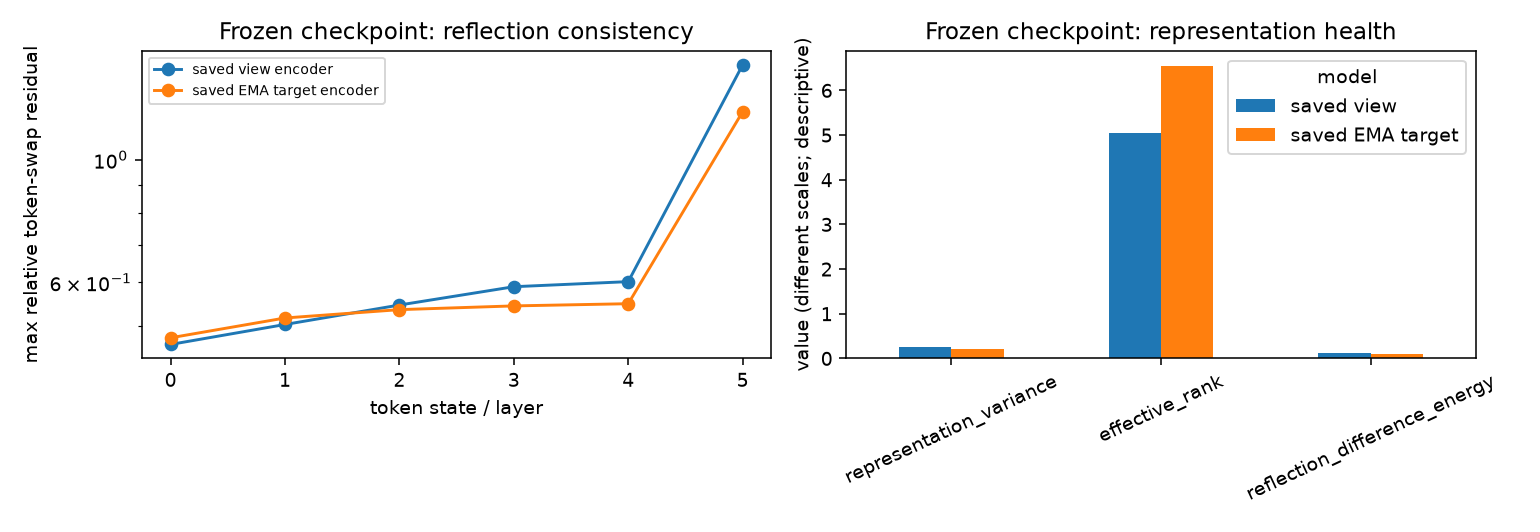

Wrote /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd5-tm/work/artifacts/real/idea9/20260818/idea9_architecture_contract.json


In [10]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
if MODE == "real":
    view_frame = pd.DataFrame(SAVED_AUDIT["view_encoder"]["token_swap"])
    target_frame = pd.DataFrame(SAVED_AUDIT["target_encoder"]["token_swap"])
    axes[0].semilogy(view_frame["layer"], np.maximum(view_frame["max_rel"], 1e-12), "o-", label="saved view encoder")
    axes[0].semilogy(target_frame["layer"], np.maximum(target_frame["max_rel"], 1e-12), "o-", label="saved EMA target encoder")
    axes[0].set(xlabel="token state / layer", ylabel="max relative token-swap residual",
                title="Frozen checkpoint: reflection consistency")
    axes[0].legend(fontsize=7)
    health_frame = pd.DataFrame([
        {"model": "saved view", **SAVED_AUDIT["view_encoder"]["health"]},
        {"model": "saved EMA target", **SAVED_AUDIT["target_encoder"]["health"]},
    ]).set_index("model")
    health_frame[["representation_variance", "effective_rank", "reflection_difference_energy"]].T.plot.bar(ax=axes[1])
    axes[1].set_title("Frozen checkpoint: representation health")
    axes[1].set_ylabel("value (different scales; descriptive)")
else:
    axes[0].semilogy(eq_online["layer"], eq_online["max_abs"], "o-", label="equivariant online")
    axes[0].semilogy(eq_teacher["layer"], eq_teacher["max_abs"], "o-", label="equivariant EMA teacher")
    axes[0].semilogy(free_online["layer"], free_online["max_abs"], "o-", label="unconstrained control")
    axes[0].axhline(TOL, ls="--", color="black", lw=1, label="contract tolerance")
    axes[0].set(xlabel="state / layer", ylabel="max swap residual", title="Layerwise commutation")
    axes[0].legend(fontsize=7)
    health_frame = pd.DataFrame([{"model": "equivariant", **eq_health},
                                 {"model": "unconstrained", **free_health}]).set_index("model")
    health_frame[["odd_energy", "odd_variance", "effective_rank"]].T.plot.bar(ax=axes[1])
    axes[1].set_title("Smoke representation-health diagnostics")
    axes[1].set_ylabel("value (different scales; illustrative)")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
figure_path = OUT_DIR / "idea9_architecture_contract.png"
fig.savefig(figure_path, dpi=140)
# The notebook deliberately uses the non-interactive Agg backend so it also works in headless
# execution. Explicitly embed the saved PNG so users still see the result in the notebook.
from IPython.display import Image, display
display(Image(filename=str(figure_path)))
plt.close(fig)

bundle = {
    "notebook": "nb_09a_equivariant_encoder_contract",
    "contract": CONTRACT,
    "saved_checkpoint_audit": SAVED_AUDIT,
    "proposal_contract_fixture": {
        "architecture": {
            "equivariant_parameters": parameter_count(equivariant),
            "unconstrained_parameters": parameter_count(unconstrained),
            "note": "Synthetic fixture only; real paired runs calibrate width to match budgets.",
        },
        "commutation": {
            "equivariant_online": eq_online.to_dict(orient="records"),
            "equivariant_teacher": eq_teacher.to_dict(orient="records"),
            "unconstrained_online": free_online.to_dict(orient="records"),
            "tolerance": TOL,
        },
        "health": {"equivariant": eq_health, "unconstrained": free_health, "gate_passed": HEALTH_GATE},
        "oddness_residual": oddness,
        "smoke_training_loss": {"equivariant": eq_loss, "unconstrained": free_loss},
    },
    "manifest_status": manifest_status,
    "verdict": (
        "C0 ARCHITECTURE CONTRACT PASSES; C1 HEALTH " + ("PASSES" if HEALTH_GATE else "FAILS")
        + " (illustrative smoke only)"
        if MODE == "smoke" else "FROZEN CHECKPOINT AUDIT COMPLETE; no downstream performance claim"
    ),
    "figure": str(figure_path),
}
bundle_path = OUT_DIR / "idea9_architecture_contract.json"
bundle_path.write_text(json.dumps(bundle, indent=2))
print(f"Wrote {bundle_path}")